<a href="https://colab.research.google.com/github/akashde1998-Alpha/GCN-by-pytorch-/blob/main/GCN_by_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This cell imports necessary libraries for deep learning, plotting, and graph operations. It also installs `pytorch_lightning` and sets the device to GPU if available, otherwise CPU.

In [ ]:
# import important libbraries

import os
import math
import numpy as np
import time

#for plotting

import matplotlib.pyplot as plt
import seaborn as sns

import tqdm

# pytorch

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

# torchvision
import torchvision
from torchvision.datasets import CIFAR10
from torchvision import transforms

!pip install pytorch_lightning
import pytorch_lightning as pl
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 33.8 MB/s eta 0:00:00
cpu


This cell defines the `GCNLayer` as a PyTorch module. It implements a basic Graph Convolutional Network (GCN) layer, performing a linear projection, followed by aggregation of neighborhood features.

In [ ]:
# As a pytorch module

class GCNLayer(nn.Module):

    def __init__(self,c_in,c_out):
        super().__init__()
        self.projection = nn.Linear(c_in,c_out)

    def forward(self,node_feats,adj_matrix):
        #num_neighbors = number of incoming edges
        num_neighbors = adj_matrix.sum(dim = -1,keepdims=True)
        #num_neighbors = adj_matrix @ torch.ones((adj_matrix.size(1), 1))
        node_feats = self.projection(node_feats)
        node_feats = torch.bmm(adj_matrix,node_feats)
        node_feats = node_feats / num_neighbors
        return node_feats


This cell demonstrates the GCNLayer on an example graph. It uses the `networkx` library to create a simple graph and then visualizes it using `matplotlib`.

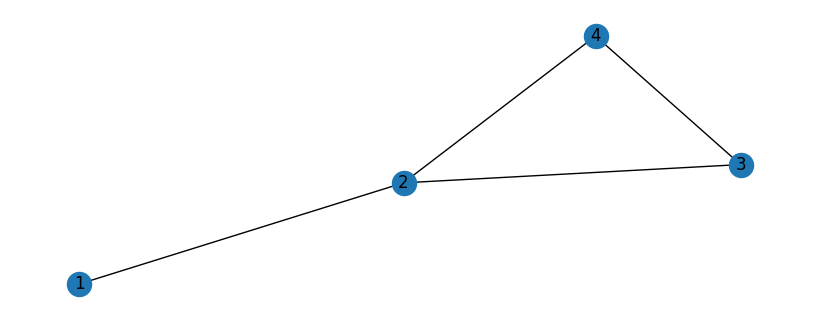

In [ ]:

# let's apply it to example graph

import networkx as nx

# creating graph from external resources
nx_g = nx.from_edgelist([(2,1), (2,3), (4,2), (3,4)])

import matplotlib.pyplot as plt

# nx.draw(g, with_labels=True)
# plt.show()

fig = plt.figure(figsize=(8, 3))
nx.draw(nx_g, with_labels=True)

This cell defines initial node features and constructs an adjacency matrix for the graph. It converts the `networkx` graph into a PyTorch tensor adjacency matrix and adds self-loops to it.

In [ ]:

node_feats = torch.arange(8, dtype=torch.float32).view(1, 4, 2)
A = torch.tensor(
    nx.to_numpy_array(nx_g),
    dtype=torch.float32
)

I = torch.eye(A.shape[0])

adj_matrix = A + I

adj_matrix = adj_matrix.unsqueeze(0)

display(adj_matrix)
print("Node features:\n", node_feats)

tensor([[[1., 1., 1., 1.],
         [1., 1., 0., 0.],
         [1., 0., 1., 1.],
         [1., 0., 1., 1.]]])

Node features:
 tensor([[[0., 1.],
         [2., 3.],
         [4., 5.],
         [6., 7.]]])


This cell initializes and demonstrates two `GCNLayer` instances. It sets custom weights and biases for the projection layers and then applies them sequentially to the node features and adjacency matrix to compute output features.

In [ ]:
layer_1 = GCNLayer(c_in=2, c_out=2)
layer_2 = GCNLayer(c_in=2, c_out=3)


layer_1.projection.weight.data = torch.Tensor([[1., 2.], [0., 1.]])
layer_1.projection.bias.data = torch.Tensor([0., 0.])
layer_2.projection.weight.data = torch.Tensor([[1., 2.], [0., 1.],[1.,0.]])
layer_2.projection.bias.data = torch.Tensor([0., 0., 0.])
with torch.no_grad():
   x_1= layer_1(node_feats, adj_matrix)
   out_feats=layer_2(x_1,adj_matrix)


print("x_1=",x_1)
print("Adjacency matrix", adj_matrix)
print("Input feature", node_feats)
print("Output features", out_feats)

x_1= tensor([[[11.0000,  4.0000],
         [ 5.0000,  2.0000],
         [12.0000,  4.3333],
         [12.0000,  4.3333]]])
Adjacency matrix tensor([[[1., 1., 1., 1.],
         [1., 1., 0., 0.],
         [1., 0., 1., 1.],
         [1., 0., 1., 1.]]])
Input feature tensor([[[0., 1.],
         [2., 3.],
         [4., 5.],
         [6., 7.]]])
Output features tensor([[[17.3333,  3.6667, 10.0000],
         [14.0000,  3.0000,  8.0000],
         [20.1111,  4.2222, 11.6667],
         [20.1111,  4.2222, 11.6667]]])
